In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/london-and-leicestershire-crime-data/2022-10-leicestershire-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-02-leicestershire-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-04-city-of-london-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-07-leicestershire-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-02-city-of-london-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-10-city-of-london-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-11-leicestershire-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-06-leicestershire-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-12-leicestershire-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-01-leicestershire-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-08-leicestershire-street.csv
/kaggle/input/london-and-leicestershire-crime-data/2022-05-city-o

In [3]:
!pip install pyspark==3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.3/281.3 MB 3.0 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.8/198.8 kB 10.9 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.2.0-py2.py3-none-any.whl size=281805893 sha256=95d3134eb75776664612a50f25cbe03b9e848a5180e4e4a65ceddbc03b9b514a
  Stored in directory: /root/.cache/pip/wheels/32/97/d3/8b6d964c8700e4fbb561c71638a92ec55dac9be51eb5fea86d
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.7
    Uninstalling py4j-0.10.9.7:
      Successfully uninstalled py4j-0.10.9.7


In [4]:
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession, SQLContext
spark = SparkSession.builder.master("local[2]").appName("dataframe").getOrCreate()
sc = spark.sparkContext
sqlContext = SQLContext(spark)

Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/01/23 21:27:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
/opt/conda/lib/python3.10/site-packages/pyspark/sql/context.py:77: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [5]:
from io import StringIO
from collections import namedtuple
from pyspark.sql import Row
from pyspark.sql.types import *
from pyspark.sql.functions import *

import csv
import matplotlib.pyplot as plt
# import gmplot
import pandas as pd
import numpy as np

In [6]:
crime_DF = spark.read.option("header", "true").option("delimiter", ",")\
.option("inferSchema", "true").csv("/kaggle/input/london-and-leicestershire-crime-data")

In [7]:
crime_DF.printSchema()

root
 |-- Crime ID: string (nullable = true)
 |-- Month: string (nullable = true)
 |-- Reported by: string (nullable = true)
 |-- Falls within: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- LSOA code: string (nullable = true)
 |-- LSOA name: string (nullable = true)
 |-- Crime type: string (nullable = true)
 |-- Last outcome category: string (nullable = true)
 |-- Context: string (nullable = true)



In [8]:
crime_DF = crime_DF = crime_DF.withColumnRenamed('crime ID','crime_ID')
crime_DF = crime_DF = crime_DF.withColumnRenamed('Reported by','Reported_by')
crime_DF = crime_DF = crime_DF.withColumnRenamed('Falls Within','Falls_within')
crime_DF = crime_DF = crime_DF.withColumnRenamed('LSOA code','LSOA_code')
crime_DF = crime_DF = crime_DF.withColumnRenamed('LSOA name','LSOA_name')
crime_DF = crime_DF.withColumnRenamed('Crime type', 'Crime_type')
crime_DF = crime_DF.withColumnRenamed('Last outcome category', 'Last_outcome_category')

In [9]:
crime_DF.printSchema()

root
 |-- crime_ID: string (nullable = true)
 |-- Month: string (nullable = true)
 |-- Reported_by: string (nullable = true)
 |-- Falls_within: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- LSOA_code: string (nullable = true)
 |-- LSOA_name: string (nullable = true)
 |-- Crime_type: string (nullable = true)
 |-- Last_outcome_category: string (nullable = true)
 |-- Context: string (nullable = true)



In [10]:
# Create new data frame with Month and Counts per Month
crime_DF2 = crime_DF.select(crime_DF.Month)\
.groupby(crime_DF.Month).count()

In [11]:
crime_DF2.printSchema()

root
 |-- Month: string (nullable = true)
 |-- count: long (nullable = false)



In [12]:
crime_DF2.orderBy(desc("Month")).show()

+-------+-----+
|  Month|count|
+-------+-----+
|2022-12| 9338|
|2022-11|10564|
|2022-10|10588|
|2022-09|10191|
|2022-08|11156|
|2022-07|10842|
|2022-06|10668|
|2022-05|11050|
|2022-04|10148|
|2022-03|10706|
|2022-02| 9074|
|2022-01| 9323|
+-------+-----+



In [13]:

monthlyCrimeAmount = sqlContext
"SELECT substring(Month, 6, 2) AS Month, \
    SUM(count) AS Total, avg(count) AS Average \
    FROM tbl_crime_DF2 \
    WHERE `Reported By` = 'Leicestershire Police' \
    GROUP BY substring(Month, 6, 2))"



"SELECT substring(Month, 6, 2) AS Month,     SUM(count) AS Total, avg(count) AS Average     FROM tbl_crime_DF2     WHERE `Reported By` = 'Leicestershire Police'     GROUP BY substring(Month, 6, 2))"

In [14]:
crime_DF2.registerTempTable("tbl_crime_DF2")

/opt/conda/lib/python3.10/site-packages/pyspark/sql/dataframe.py:138: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn(


In [15]:
# Create new dataframe with month, total, and averages
monthlyCrimeAmount = sqlContext.\
sql("select substring(Month, 6, 2) as Month, \
SUM(count) as Total, avg(count) as \
Average from tbl_crime_DF2 group by substring(Month, 6, 2)")

In [16]:
monthlyCrimeAmountnew = monthlyCrimeAmount.orderBy('Month')

In [17]:
monthlyCrimeAmountnew.show()

+-----+-----+-------+
|Month|Total|Average|
+-----+-----+-------+
|   01| 9323| 9323.0|
|   02| 9074| 9074.0|
|   03|10706|10706.0|
|   04|10148|10148.0|
|   05|11050|11050.0|
|   06|10668|10668.0|
|   07|10842|10842.0|
|   08|11156|11156.0|
|   09|10191|10191.0|
|   10|10588|10588.0|
|   11|10564|10564.0|
|   12| 9338| 9338.0|
+-----+-----+-------+



In [18]:
# Register the monthlyCrimeAmount 
# DataFrame as a temp table and show the contents
monthlyCrimeAmountnew.registerTempTable("monthlyCrimeAmount")
sqlContext.sql("select * from monthlyCrimeAmount").show()

+-----+-----+-------+
|Month|Total|Average|
+-----+-----+-------+
|   01| 9323| 9323.0|
|   02| 9074| 9074.0|
|   03|10706|10706.0|
|   04|10148|10148.0|
|   05|11050|11050.0|
|   06|10668|10668.0|
|   07|10842|10842.0|
|   08|11156|11156.0|
|   09|10191|10191.0|
|   10|10588|10588.0|
|   11|10564|10564.0|
|   12| 9338| 9338.0|
+-----+-----+-------+



In [19]:
monthArray = sqlContext.sql("select Month from monthlyCrimeAmount")\
.rdd.map(lambda f:f[0]).collect()
monthTotalArray = sqlContext.sql("select Total from monthlyCrimeAmount")\
.rdd.map(lambda f:f[0]).collect()
monthAvgArray = sqlContext.sql("select Average from monthlyCrimeAmount")\
.rdd.map(lambda f:f[0]).collect()

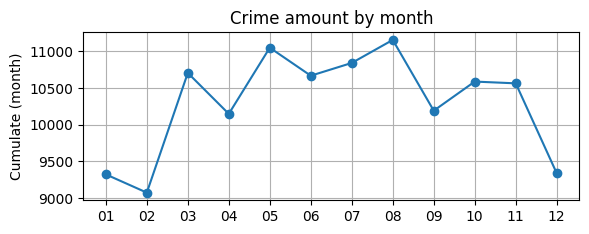

In [20]:
import matplotlib.pyplot as plt
import numpy as np

y = monthArray
t = monthTotalArray
a = monthAvgArray

plt.subplot(2, 1, 1)
plt.plot(y, t, 'o-')
plt.title('Crime amount by month')
plt.ylabel('Cumulate (month)')
plt.grid(True)
plt.show()

In [21]:
crime_DF.groupby("Reported_by").count().orderBy(desc("count")).show()

+--------------------+------+
|         Reported_by| count|
+--------------------+------+
|Leicestershire Po...|115179|
|City of London Po...|  8469|
+--------------------+------+



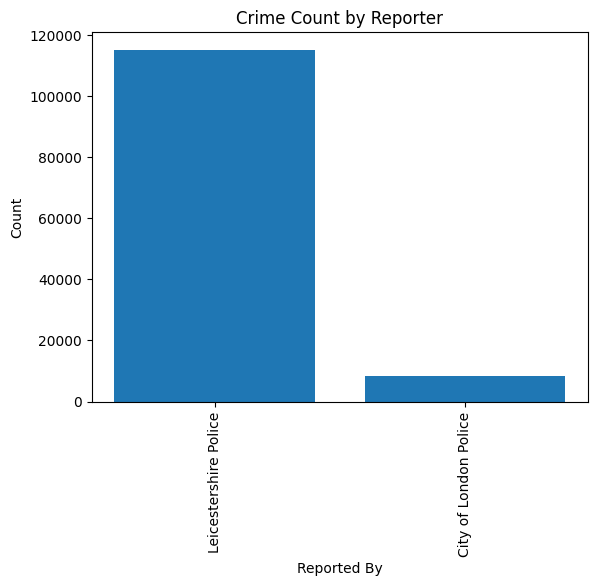

In [22]:

grouped_data = crime_DF.groupBy("Reported_by").count().orderBy("count", ascending=False)


pandas_df = grouped_data.toPandas()

# Plotting the bar chart using Matplotlib
plt.bar(pandas_df["Reported_by"], pandas_df["count"])
plt.xlabel("Reported By")
plt.ylabel("Count")
plt.title("Crime Count by Reporter")
plt.xticks(rotation=90)  
plt.show()

In [23]:
crime_DF.registerTempTable("tbl_crime_DF")

/opt/conda/lib/python3.10/site-packages/pyspark/sql/dataframe.py:138: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn(


In [24]:
sqlContext.sql("SELECT MONTH(Month) AS Month, Crime_type, COUNT(*) AS count FROM tbl_crime_DF WHERE Reported_by = 'Leicestershire Police' GROUP BY MONTH(Month), Crime_type ORDER BY Month").show(210)

+-----+--------------------+-----+
|Month|          Crime_type|count|
+-----+--------------------+-----+
|    1|Anti-social behav...|  726|
|    1|            Burglary|  407|
|    1|             Robbery|   62|
|    1|               Drugs|  269|
|    1|       Bicycle theft|  170|
|    1|         Shoplifting|  272|
|    1|         Other theft|  744|
|    1|Theft from the pe...|   50|
|    1|Violence and sexu...| 3338|
|    1|       Vehicle crime|  573|
|    1|Possession of wea...|   84|
|    1|Criminal damage a...|  899|
|    1|        Public order|  930|
|    1|         Other crime|  206|
|    2|         Other theft|  666|
|    2|Possession of wea...|   87|
|    2|       Bicycle theft|  121|
|    2|         Shoplifting|  331|
|    2|             Robbery|   45|
|    2|Theft from the pe...|   54|
|    2|Anti-social behav...|  727|
|    2|        Public order|  966|
|    2|Violence and sexu...| 3339|
|    2|               Drugs|  235|
|    2|            Burglary|  401|
|    2|       Vehicl

In [25]:
sqlContext.sql("SELECT MONTH(Month) AS Month, Crime_type, COUNT(*) AS count FROM tbl_crime_DF WHERE Reported_by = 'City of London Police' GROUP BY MONTH(Month), Crime_type ORDER BY Month").show(210)

+-----+--------------------+-----+
|Month|          Crime_type|count|
+-----+--------------------+-----+
|    1|Anti-social behav...|   78|
|    1|            Burglary|   15|
|    1|             Robbery|    4|
|    1|               Drugs|   62|
|    1|       Bicycle theft|   14|
|    1|         Shoplifting|   56|
|    1|         Other theft|   70|
|    1|Theft from the pe...|   50|
|    1|Violence and sexu...|  128|
|    1|       Vehicle crime|   15|
|    1|Possession of wea...|    8|
|    1|Criminal damage a...|   34|
|    1|        Public order|   40|
|    1|         Other crime|   19|
|    2|         Other theft|  134|
|    2|Possession of wea...|    2|
|    2|       Bicycle theft|    9|
|    2|         Shoplifting|   49|
|    2|             Robbery|    7|
|    2|Theft from the pe...|   66|
|    2|Anti-social behav...|   65|
|    2|        Public order|   40|
|    2|Violence and sexu...|   92|
|    2|               Drugs|   42|
|    2|            Burglary|   38|
|    2|       Vehicl

In [26]:
sqlContext.sql("SELECT MONTH(Month) AS Month, Crime_type, COUNT(*) AS count FROM tbl_crime_DF WHERE Reported_by = 'Leicestershire Police'GROUP BY MONTH(Month), Crime_type ORDER BY Month").show(210)

+-----+--------------------+-----+
|Month|          Crime_type|count|
+-----+--------------------+-----+
|    1|Anti-social behav...|  726|
|    1|            Burglary|  407|
|    1|             Robbery|   62|
|    1|               Drugs|  269|
|    1|       Bicycle theft|  170|
|    1|         Shoplifting|  272|
|    1|         Other theft|  744|
|    1|Theft from the pe...|   50|
|    1|Violence and sexu...| 3338|
|    1|       Vehicle crime|  573|
|    1|Possession of wea...|   84|
|    1|Criminal damage a...|  899|
|    1|        Public order|  930|
|    1|         Other crime|  206|
|    2|         Other theft|  666|
|    2|Possession of wea...|   87|
|    2|       Bicycle theft|  121|
|    2|         Shoplifting|  331|
|    2|             Robbery|   45|
|    2|Theft from the pe...|   54|
|    2|Anti-social behav...|  727|
|    2|        Public order|  966|
|    2|Violence and sexu...| 3339|
|    2|               Drugs|  235|
|    2|            Burglary|  401|
|    2|       Vehicl

In [27]:
sqlContext.sql("SELECT MONTH(Month) AS Month, Reported_by, COUNT(*) AS count FROM tbl_crime_DF WHERE Reported_by = 'City of London Police' GROUP BY MONTH(Month), Reported_by ORDER BY Month").show(210)

+-----+--------------------+-----+
|Month|         Reported_by|count|
+-----+--------------------+-----+
|    1|City of London Po...|  593|
|    2|City of London Po...|  592|
|    3|City of London Po...|  687|
|    4|City of London Po...|  654|
|    5|City of London Po...|  718|
|    6|City of London Po...|  688|
|    7|City of London Po...|  786|
|    8|City of London Po...|  783|
|    9|City of London Po...|  699|
|   10|City of London Po...|  786|
|   11|City of London Po...|  748|
|   12|City of London Po...|  735|
+-----+--------------------+-----+



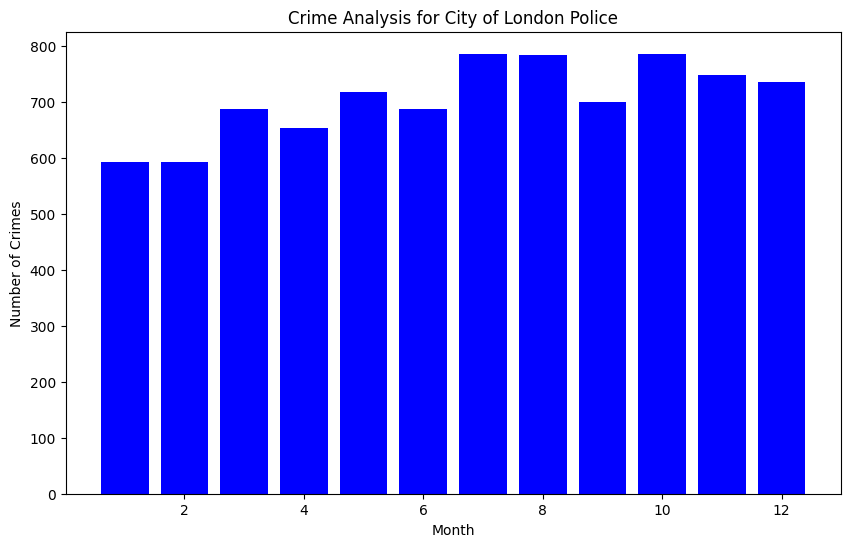

In [28]:
query = """
    SELECT MONTH(Month) AS Month, Reported_by, COUNT(*) AS count
    FROM tbl_crime_DF
    WHERE Reported_by = 'City of London Police'
    GROUP BY MONTH(Month), Reported_by
    ORDER BY Month
"""

# Execute the query and collect the results into a Pandas DataFrame
tbl_crime_DF = spark.sql(query).toPandas()

# Plotting the bar chart using Matplotlib
plt.figure(figsize=(10, 6))
plt.bar(tbl_crime_DF['Month'], tbl_crime_DF['count'], color='blue')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.title('Crime Analysis for City of London Police')
plt.show()

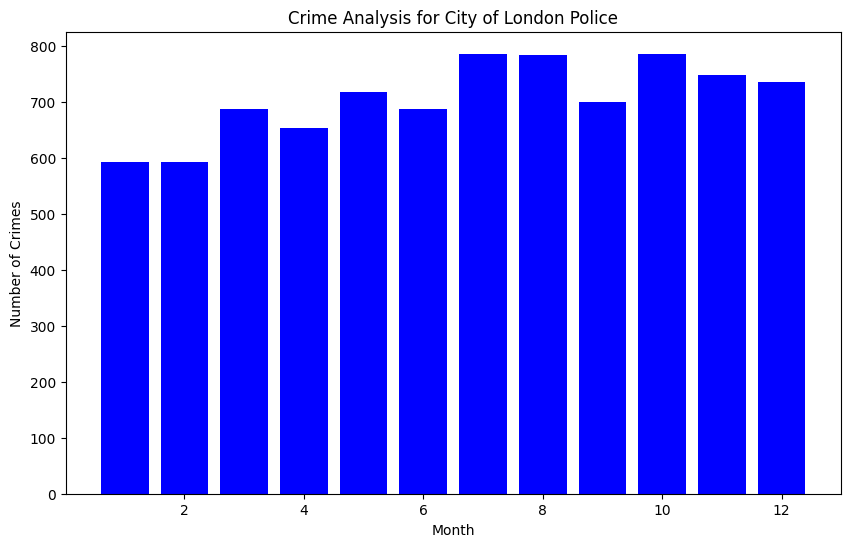

In [29]:
query = """
    SELECT MONTH(Month) AS Month, Reported_by, COUNT(*) AS count
    FROM tbl_crime_DF
    WHERE Reported_by = 'City of London Police'
    GROUP BY MONTH(Month), Reported_by
    ORDER BY Month
"""

tbl_crime_DF = spark.sql(query).toPandas()

# Plotting the bar chart using Matplotlib
plt.figure(figsize=(10, 6))
plt.bar(tbl_crime_DF['Month'], tbl_crime_DF['count'], color='blue')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.title('Crime Analysis for City of London Police')
plt.show()

In [30]:
pandas_df = result_df.toPandas()

# Plotting the bar chart using Matplotlib
plt.bar(pandas_df["Month"], pandas_df["count"])
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Crime Count by City of London Police")
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()

NameError: name 'result_df' is not defined

In [ ]:
sqlContext.sql(" SELECT Crime_type, COUNT(*) AS count FROM tbl_crime_DF WHERE Reported_by = 'City of London Police' GROUP BY Crime_type ORDER BY count DESC").show(210)

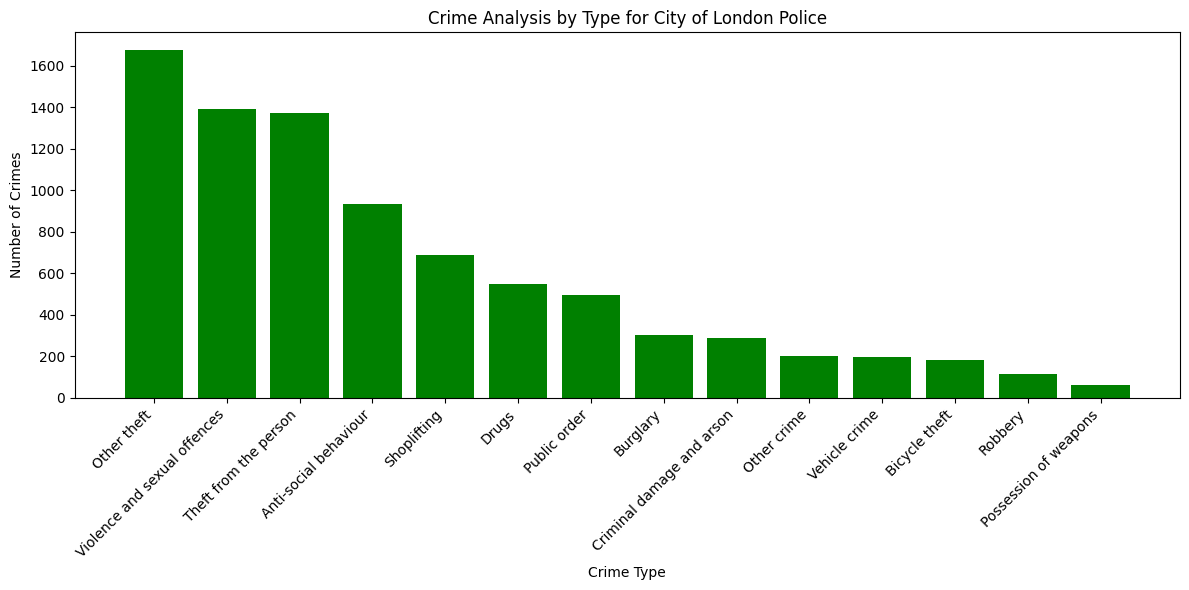

In [31]:
query = """
    SELECT Crime_type, COUNT(*) AS count
    FROM tbl_crime_DF
    WHERE Reported_by = 'City of London Police'
    GROUP BY Crime_type
    ORDER BY count DESC
"""

result_df = spark.sql(query).toPandas()

# Plotting the bar chart using Matplotlib
plt.figure(figsize=(12, 6))
plt.bar(result_df['Crime_type'], result_df['count'], color='green')
plt.xlabel('Crime Type')
plt.ylabel('Number of Crimes')
plt.title('Crime Analysis by Type for City of London Police')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  
plt.show()

In [ ]:
sqlContext.sql("SELECT Crime_type, COUNT(*) AS count FROM tbl_crime_DF WHERE Reported_by = 'Leicestershire Police'GROUP BY Crime_type ORDER BY count DESC").show(210)

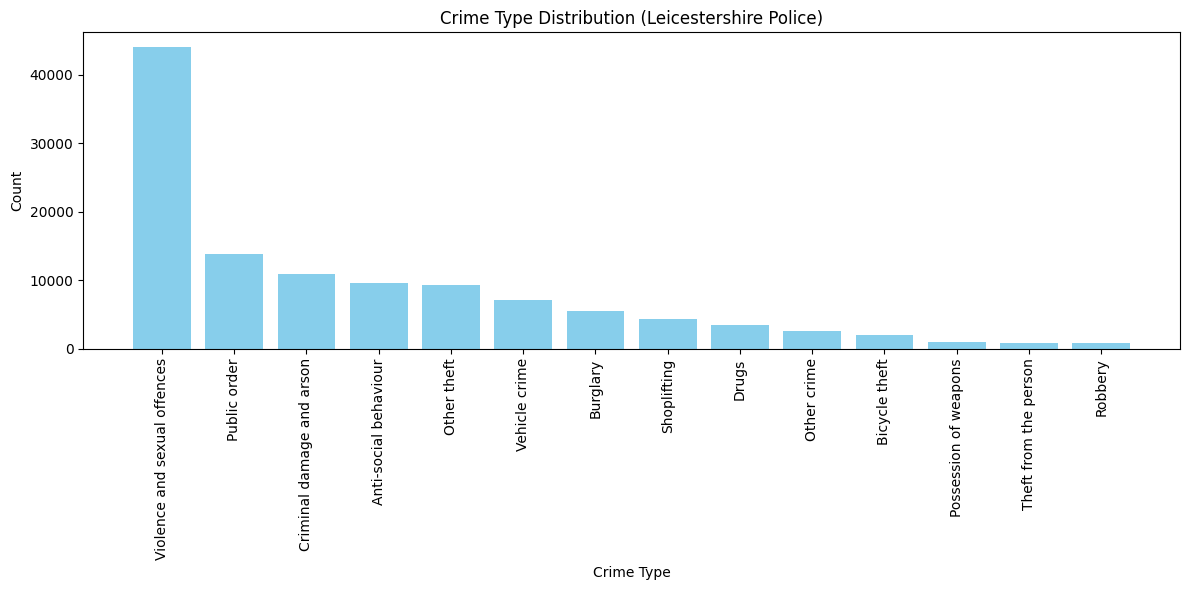

In [33]:
query = """
    SELECT Crime_type, COUNT(*) AS count
    FROM tbl_crime_DF
    WHERE Reported_by = 'Leicestershire Police'
    GROUP BY Crime_type
    ORDER BY count DESC
"""

tbl_crime_DF = spark.sql(query)


tbl_crime_pd = tbl_crime_DF.toPandas()

# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(tbl_crime_pd['Crime_type'], tbl_crime_pd['count'], color='skyblue')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.title('Crime Type Distribution (Leicestershire Police)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
sqlContext.sql("SELECT MONTH(Month) AS Month, Reported_by, COUNT(*) AS count FROM tbl_crime_DF WHERE Reported_by = 'Leicestershire Police'GROUP BY MONTH(Month), Reported_by ORDER BY Month").show(210)    

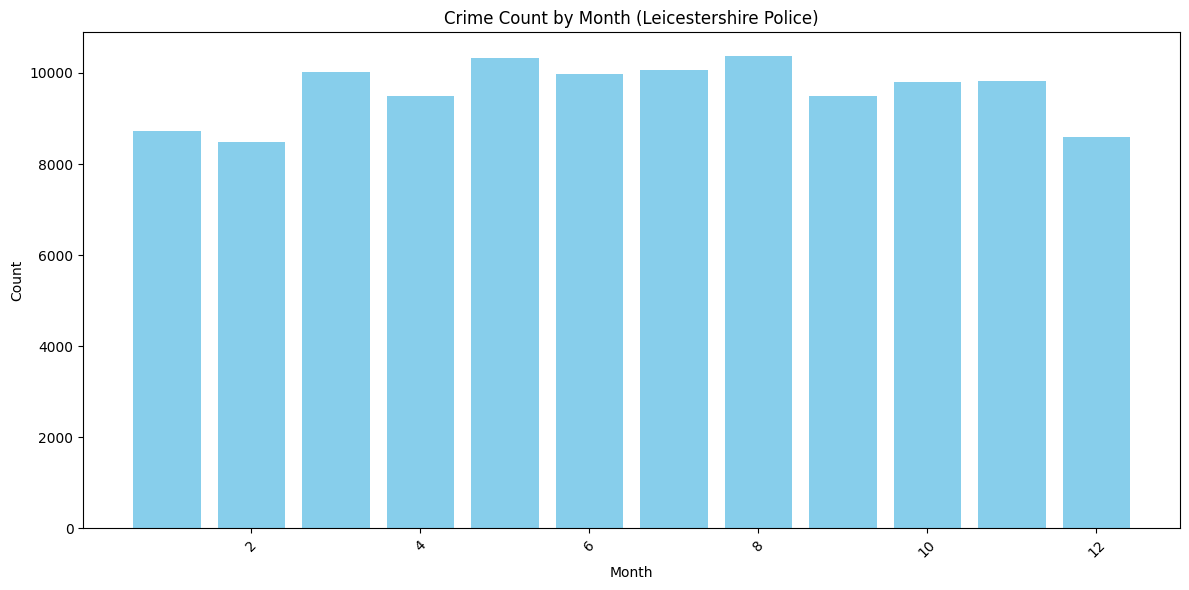

In [37]:
query = """
    SELECT MONTH(Month) AS Month, Reported_by, COUNT(*) AS count
    FROM tbl_crime_DF
    WHERE Reported_by = 'Leicestershire Police'
    GROUP BY MONTH(Month), Reported_by
    ORDER BY Month
"""

tbl_crime_DF = spark.sql(query)


tbl_crime_pd = tbl_crime_DF.toPandas()

# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(tbl_crime_pd['Month'], tbl_crime_pd['count'], color='skyblue')
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Crime Count by Month (Leicestershire Police)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()